# Setting

In [23]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, Tuple

import numpy as np
import matplotlib.pyplot as plt

In [24]:
import rclpy

import rosbag2_py
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message

import pandas as pd
import matplotlib.pyplot as plt

import os
from PIL import Image

## Read ROSBAG

In [25]:
def read_messages(input_bag: str):
    reader = rosbag2_py.SequentialReader()
    reader.open(
        rosbag2_py.StorageOptions(uri=input_bag, storage_id="sqlite3"),
        rosbag2_py.ConverterOptions(
            input_serialization_format="", output_serialization_format=""
        ),
    )

    topic_types = reader.get_all_topics_and_types()

    def typename(topic_name):
        for topic_type in topic_types:
            if topic_type.name == topic_name:
                return topic_type.type
        raise ValueError(f"topic {topic_name} not in bag")

    while reader.has_next():
        topic, data, timestamp = reader.read_next()
        msg_type = get_message(typename(topic))
        msg = deserialize_message(data, msg_type)
        yield topic, msg, timestamp
    del reader

In [26]:
def get_df_from_record(record_name: str):
    odom_topic_data = {
        "timestamp": [],
        "header_stamp": [],
        "linear":[], 
        "angular":[]
    }

    cmd_vel_topic_data = {
        "timestamp": [],
        "linear":[], 
        "angular":[]
    }

    for topic, msg, timestamp in read_messages(record_name):
        if topic == "/odom":
            odom_topic_data["timestamp"].append(timestamp)
            odom_topic_data["header_stamp"].append(msg.header.stamp)
            odom_topic_data["linear"].append(msg.twist.twist.linear.x)
            odom_topic_data["angular"].append(msg.twist.twist.angular.z)
        elif topic == "/cmd_vel":
            cmd_vel_topic_data["timestamp"].append(timestamp)
            cmd_vel_topic_data["linear"].append(msg.linear.x)
            cmd_vel_topic_data["angular"].append(msg.angular.z)
    
    actual_df = pd.DataFrame.from_dict(odom_topic_data)
    cmd_df = pd.DataFrame.from_dict(cmd_vel_topic_data)

    # Align the dataframes based on timestamps
    if actual_df.timestamp[0] - cmd_df.timestamp[0] < 0:
        start_idx = (actual_df.timestamp - cmd_df.timestamp[0]).abs().idxmin()
        actual_df = actual_df[start_idx:].reset_index(drop=True)
    else:
        start_idx = (cmd_df.timestamp - actual_df.timestamp[0]).abs().idxmin()
        cmd_df = cmd_df[start_idx:].reset_index(drop=True)

    end_index = min(len(actual_df), len(cmd_df))
    actual_df = actual_df[:end_index].reset_index(drop=True)
    cmd_df = cmd_df[:end_index].reset_index(drop=True)

    print(f"Data length of odom:", len(actual_df))
    print(f"Data length of cmd_vel:", len(cmd_df))

    return actual_df, cmd_df

## Data Class definition

In [27]:
@dataclass
class SimulationConfig:
    dt: float = 0.01
    T: float = 30.0
    seed: int = 7


@dataclass
class EffectiveModelConfig:
    # Hidden closed-loop response model:
    #
    #   dv/dt     = a1 * v_cmd     + a2 * v
    #   domega/dt = a3 * omega_cmd + a4 * omega

    m_eff: float = 1.5
    I_eff: float = 0.8

    K_v: float = 2.0
    K_omega: float = 2.5

    d_v: float = 0.8
    d_omega: float = 0.6

    def coefficients(self) -> tuple[float, float, float, float]:
        a1 = self.K_v / self.m_eff
        a2 = -(self.K_v + self.d_v) / self.m_eff

        a3 = self.K_omega / self.I_eff
        a4 = -(self.K_omega + self.d_omega) / self.I_eff

        return a1, a2, a3, a4


@dataclass
class InputConfig:
    segment_duration: float = 3.0

    v_cmd_levels: tuple[float, ...] = (
        0.0, 0.5, 1.0, -0.3, 0.8,
        0.0, 1.0, -0.4, 0.6, 0.0,
    )

    omega_cmd_levels: tuple[float, ...] = (
        0.0, 0.6, -0.6, 0.0, 0.9,
        -0.9, 0.0, 0.5, -0.5, 0.0,
    )


@dataclass
class FilterConfig:
    lam: float = 8.0
    drem_delay: float = 0.5


@dataclass
class NoiseConfig:
    v_std: float = 0.01
    omega_std: float = 0.01


@dataclass
class RLSConfig:
    forgetting: float = 0.995
    P0: float = 100.0


@dataclass
class DREMConfig:
    gamma_v: tuple[float, float] = (4.0, 2.0)
    gamma_w: tuple[float, float] = (4.0, 2.0)


@dataclass
class GradientConfig:
    Gamma_v: np.ndarray = field(
        default_factory=lambda: np.diag([2.0, 1.0])
    )

    Gamma_w: np.ndarray = field(
        default_factory=lambda: np.diag([2.0, 1.0])
    )


@dataclass
class FiniteTimeDREMConfig:
    gamma_v: tuple[float, float] = (4.0, 2.0)
    gamma_w: tuple[float, float] = (4.0, 2.0)

    mu_v: tuple[float, float] = (0.95, 0.95)
    mu_w: tuple[float, float] = (0.95, 0.95)

    eps: float = 1e-8


@dataclass
class ExperimentConfig:
    sim: SimulationConfig = field(default_factory=SimulationConfig)

    model: EffectiveModelConfig = field(
        default_factory=EffectiveModelConfig
    )

    inputs: InputConfig = field(
        default_factory=InputConfig
    )

    filt: FilterConfig = field(
        default_factory=FilterConfig
    )

    noise: NoiseConfig = field(
        default_factory=NoiseConfig
    )

    rls: RLSConfig = field(
        default_factory=RLSConfig
    )

    drem: DREMConfig = field(
        default_factory=DREMConfig
    )

    grad: GradientConfig = field(
        default_factory=GradientConfig
    )

    ftdrem: FiniteTimeDREMConfig = field(
        default_factory=FiniteTimeDREMConfig
    )

class LowPassFilter:
    def __init__(self, alpha):
        """
        alpha: Smoothing factor (0.0 to 1.0). 
               Lower = smoother but more lag.
               Higher = noisier but faster response.
        """
        self.alpha = alpha
        self.avg_sin = None
        self.avg_cos = None

    def filter(self, current_angle):
        # Convert angle to vector components
        curr_sin = np.sin(current_angle)
        curr_cos = np.cos(current_angle)

        if self.avg_sin is None:
            self.avg_sin = curr_sin
            self.avg_cos = curr_cos
        else:
            # Apply Exponential Moving Average (EMA) to components
            self.avg_sin = (self.alpha * curr_sin) + (1.0 - self.alpha) * self.avg_sin
            self.avg_cos = (self.alpha * curr_cos) + (1.0 - self.alpha) * self.avg_cos

        # Recombine using atan2 to handle the -pi to pi wrap-around
        return np.arctan2(self.avg_sin, self.avg_cos)


## Estimator definition

In [28]:

class RLSEstimator:
    def __init__(self, cfg: RLSConfig):
        self.cfg = cfg

    def estimate(self, phi: np.ndarray, y: np.ndarray, theta0: np.ndarray) -> np.ndarray:
        N, n = phi.shape
        theta = np.zeros((N, n))
        theta[0] = theta0

        P = np.eye(n) * self.cfg.P0
        lam = self.cfg.forgetting

        for k in range(N - 1):
            ph = phi[k].reshape(n, 1)
            y_hat = float(ph.T @ theta[k].reshape(n, 1))
            err = y[k] - y_hat

            denom = lam + float(ph.T @ P @ ph)
            K = (P @ ph) / denom

            theta[k + 1] = theta[k] + K.flatten() * err
            P = (P - K @ ph.T @ P) / lam

        return theta


class GradientEstimator:
    def __init__(self, Gamma: np.ndarray, dt: float):
        self.Gamma = Gamma
        self.dt = dt

    def estimate(self, phi: np.ndarray, y: np.ndarray, theta0: np.ndarray) -> np.ndarray:
        N, n = phi.shape
        theta = np.zeros((N, n))
        theta[0] = theta0

        for k in range(N - 1):
            ph = phi[k].reshape(n, 1)
            y_hat = float(ph.T @ theta[k].reshape(n, 1))
            err = y[k] - y_hat

            dtheta = (self.Gamma @ ph).flatten() * err
            theta[k + 1] = theta[k] + self.dt * dtheta

        return theta


class DREMEstimator:
    def __init__(self, gamma: tuple[float, float], delay: float, dt: float):
        self.gamma = gamma
        self.delay_steps = max(1, int(delay / dt))
        self.dt = dt

    def estimate(self, phi: np.ndarray, y: np.ndarray, theta0: np.ndarray) -> Dict[str, np.ndarray]:
        N, n = phi.shape
        if n != 2:
            raise ValueError("DREMEstimator assumes a 2-parameter regression.")

        theta = np.zeros((N, 2))
        theta[: self.delay_steps + 1] = theta0

        Delta = np.zeros(N)
        Psi = np.zeros((N, 2))

        for k in range(self.delay_steps, N - 1):
            a, b = phi[k, 0], phi[k, 1]
            c, d = phi[k - self.delay_steps, 0], phi[k - self.delay_steps, 1]

            y1 = y[k]
            y2 = y[k - self.delay_steps]

            Delta[k] = a * d - b * c

            Psi[k, 0] = d * y1 - b * y2
            Psi[k, 1] = -c * y1 + a * y2

            for i in range(2):
                theta[k + 1, i] = theta[k, i] - self.dt * self.gamma[i] * Delta[k] * (
                    Delta[k] * theta[k, i] - Psi[k, i]
                )

        return {
            "theta": theta,
            "Delta": Delta,
            "Psi": Psi,
            "Delta_energy": np.cumsum(Delta**2) * self.dt,
        }

In [29]:
class FiniteTimeDREMEstimator:
    """
    Finite-time DREM reconstruction wrapper.

    Scalar DREM regression:
        Psi_i(t) = Delta(t) * theta_i

    Base scalar gradient estimator:
        d theta_hat_i / dt =
            gamma_i * Delta(t) * (Psi_i(t) - Delta(t) * theta_hat_i)

    Auxiliary variable:
        d w_i / dt = - gamma_i * Delta(t)^2 * w_i,
        w_i(0) = 1

    Clipping:
        w_c,i(t) = mu_i, if w_i(t) >= mu_i
                 = w_i(t), otherwise

    Finite-time reconstructed estimate:
        theta_F,i =
            (theta_hat_i - w_c,i * theta_hat_i(0)) / (1 - w_c,i)

    Finite-time condition:
        integral Delta^2 >= -(1/gamma_i) * ln(mu_i)

    Important:
        - mu_i is a threshold for w_i.
        - smaller mu_i means later but more reliable reconstruction.
        - larger mu_i means earlier but more noise-sensitive reconstruction.
    """

    def __init__(
        self,
        gamma: tuple[float, float],
        mu: tuple[float, float],
        delay: float,
        dt: float,
        eps: float = 1e-8,
    ):
        self.gamma = gamma
        self.mu = mu
        self.delay_steps = max(1, int(delay / dt))
        self.dt = dt
        self.eps = eps

        for mu_i in mu:
            if not (0.0 < mu_i < 1.0):
                raise ValueError("Each mu_i must satisfy 0 < mu_i < 1.")

    def estimate(
        self,
        phi: np.ndarray,
        y: np.ndarray,
        theta0: np.ndarray,
    ) -> Dict[str, np.ndarray]:

        N, n = phi.shape

        if n != 2:
            raise ValueError("FiniteTimeDREMEstimator assumes a 2-parameter regression.")

        theta = np.zeros((N, 2))
        theta_F = np.zeros((N, 2))

        theta[: self.delay_steps + 1] = theta0
        theta_F[: self.delay_steps + 1] = theta0

        Delta = np.zeros(N)
        Psi = np.zeros((N, 2))

        w = np.ones((N, 2))
        w_clip = np.ones((N, 2))
        finite_time_active = np.zeros((N, 2), dtype=bool)

        for k in range(self.delay_steps, N - 1):
            a, b = phi[k, 0], phi[k, 1]
            c, d = phi[k - self.delay_steps, 0], phi[k - self.delay_steps, 1]

            y1 = y[k]
            y2 = y[k - self.delay_steps]

            Delta[k] = a * d - b * c

            Psi[k, 0] = d * y1 - b * y2
            Psi[k, 1] = -c * y1 + a * y2

            for i in range(2):
                gamma_i = self.gamma[i]
                mu_i = self.mu[i]

                # base scalar DREM gradient estimator
                theta_dot = gamma_i * Delta[k] * (
                    Psi[k, i] - Delta[k] * theta[k, i]
                )
                theta[k + 1, i] = theta[k, i] + self.dt * theta_dot

                # auxiliary w dynamics
                w_dot = -gamma_i * (Delta[k] ** 2) * w[k, i]
                w[k + 1, i] = w[k, i] + self.dt * w_dot
                w[k + 1, i] = np.clip(w[k + 1, i], 0.0, 1.0)

                # clipping exactly as in your formula:
                # if w >= mu -> use mu, else use w
                if w[k + 1, i] >= mu_i:
                    w_clip[k + 1, i] = mu_i
                    finite_time_active[k + 1, i] = False
                else:
                    w_clip[k + 1, i] = w[k + 1, i]
                    finite_time_active[k + 1, i] = True

                denom = 1.0 - w_clip[k + 1, i]
                denom = max(denom, self.eps)

                theta_F[k + 1, i] = (
                    theta[k + 1, i] - w_clip[k + 1, i] * theta0[i]
                ) / denom

        return {
            "theta": theta,
            "theta_F": theta_F,
            "Delta": Delta,
            "Psi": Psi,
            "w": w,
            "w_clip": w_clip,
            "finite_time_active": finite_time_active,
            "Delta_energy": np.cumsum(Delta**2) * self.dt,
        }

## Experiment object

In [30]:
class EffectiveInertialResponseExperiment:
    """
    Synthetic benchmark for identifying constant effective inertial response coefficients.

    Model:
        dv/dt     = a1 * v_cmd     + a2 * v
        domega/dt = a3 * omega_cmd + a4 * omega

    The coefficients are not direct physical mass/inertia estimates.
    They represent closed-loop effective response parameters.
    """

    def __init__(self, cfg: ExperimentConfig, record=None):
        self.cfg = cfg
        self.is_sim = record is None
        self.record_path = record

        if record is None:
            # If a record is provided, we will override the simulation time and timestamps.
            self.dt = cfg.sim.dt
            self.T = cfg.sim.T
            self.t = np.arange(0.0, self.T + self.dt, self.dt)
            
        else:
            self.actual_df, self.cmd_df = get_df_from_record(
                record_name=record
            )
            self.dt = self.actual_df.timestamp.diff().mean() / 1e9
            self.T = int((self.actual_df.timestamp.max() - self.actual_df.timestamp[0]) / 1e9)
            self.t = self.actual_df.timestamp.to_numpy() / 1e9 - self.actual_df.timestamp[0] / 1e9

            self.linear_lpf  = LowPassFilter(alpha=0.5)
            self.angular_lpf = LowPassFilter(alpha=0.5)

        self.N = len(self.t)
        self.rng = np.random.default_rng(cfg.sim.seed)
        self.results: Dict[str, np.ndarray] = {}

    @staticmethod
    def rmse(x: np.ndarray) -> float:
        return float(np.sqrt(np.mean(x**2)))

    def _build_truth(self) -> None:
        a1, a2, a3, a4 = self.cfg.model.coefficients()

        self.results.update({
            "a1_true": np.full(self.N, a1),
            "a2_true": np.full(self.N, a2),
            "a3_true": np.full(self.N, a3),
            "a4_true": np.full(self.N, a4),
        })

    def _build_inputs(self) -> None:
        inp = self.cfg.inputs

        v_cmd = np.zeros(self.N)
        w_cmd = np.zeros(self.N)

        seg = max(1, int(inp.segment_duration / self.dt))

        for k in range(0, self.N, seg):
            idx = (k // seg) % len(inp.v_cmd_levels)
            v_cmd[k:k + seg] = inp.v_cmd_levels[idx]
            w_cmd[k:k + seg] = inp.omega_cmd_levels[idx]

        self.results.update({
            "v_cmd": v_cmd,
            "w_cmd": w_cmd,
        })

    def _simulate_response(self) -> None:
        r = self.results
        noise = self.cfg.noise

        v = np.zeros(self.N)
        w = np.zeros(self.N)

        a1 = r["a1_true"]
        a2 = r["a2_true"]
        a3 = r["a3_true"]
        a4 = r["a4_true"]

        for k in range(self.N - 1):
            dv = a1[k] * r["v_cmd"][k] + a2[k] * v[k]
            dw = a3[k] * r["w_cmd"][k] + a4[k] * w[k]

            v[k + 1] = v[k] + self.dt * dv
            w[k + 1] = w[k] + self.dt * dw

        v_meas = v + noise.v_std * self.rng.standard_normal(self.N)
        w_meas = w + noise.omega_std * self.rng.standard_normal(self.N)

        self.results.update({
            "v": v,
            "w": w,
            "v_meas": v_meas,
            "w_meas": w_meas,
        })

    def _filtered_regression(
        self,
        measured_signal: np.ndarray,
        command_signal: np.ndarray,
    ) -> Tuple[np.ndarray, np.ndarray]:
        lam = self.cfg.filt.lam

        eta = np.zeros(self.N)
        phi_cmd = np.zeros(self.N)
        phi_state = np.zeros(self.N)
        y = np.zeros(self.N)

        for k in range(self.N - 1):
            eta[k + 1] = eta[k] + self.dt * (-lam * eta[k] + lam * measured_signal[k])

            phi_cmd[k + 1] = phi_cmd[k] + self.dt * (
                -lam * phi_cmd[k] + lam * command_signal[k]
            )

            phi_state[k + 1] = phi_state[k] + self.dt * (
                -lam * phi_state[k] + lam * measured_signal[k]
            )

            y[k + 1] = lam * (measured_signal[k + 1] - eta[k + 1])

        phi = np.column_stack((phi_cmd, phi_state))
        return y, phi

    def _build_regressions(self) -> None:
        r = self.results

        y_v, phi_v = self._filtered_regression(r["v_meas"], r["v_cmd"])
        y_w, phi_w = self._filtered_regression(r["w_meas"], r["w_cmd"])

        self.results.update({
            "y_v": y_v,
            "phi_v": phi_v,
            "y_w": y_w,
            "phi_w": phi_w,
        })

    def _initial_guess(self) -> tuple[np.ndarray, np.ndarray]:
        # For synthetic testing we initialize near the true scale but not exactly.
        r = self.results

        theta0_v = np.array([
            0.8 * r["a1_true"][0],
            0.8 * r["a2_true"][0],
        ])

        theta0_w = np.array([
            0.8 * r["a3_true"][0],
            0.8 * r["a4_true"][0],
        ])

        return theta0_v, theta0_w

    def _run_estimators(self) -> None:
        r = self.results

        theta0_v, theta0_w = self._initial_guess()

        rls = RLSEstimator(self.cfg.rls)

        grad_v = GradientEstimator(self.cfg.grad.Gamma_v, self.dt)
        grad_w = GradientEstimator(self.cfg.grad.Gamma_w, self.dt)

        drem_v = DREMEstimator(
            self.cfg.drem.gamma_v,
            self.cfg.filt.drem_delay,
            self.dt,
        )
        drem_w = DREMEstimator(
            self.cfg.drem.gamma_w,
            self.cfg.filt.drem_delay,
            self.dt,
        )

        ftdrem_v = FiniteTimeDREMEstimator(
            gamma=self.cfg.ftdrem.gamma_v,
            mu=self.cfg.ftdrem.mu_v,
            delay=self.cfg.filt.drem_delay,
            dt=self.dt,
            eps=self.cfg.ftdrem.eps,
        )
        
        ftdrem_w = FiniteTimeDREMEstimator(
            gamma=self.cfg.ftdrem.gamma_w,
            mu=self.cfg.ftdrem.mu_w,
            delay=self.cfg.filt.drem_delay,
            dt=self.dt,
            eps=self.cfg.ftdrem.eps,
        )

        theta_rls_v = rls.estimate(r["phi_v"], r["y_v"], theta0_v)
        theta_rls_w = rls.estimate(r["phi_w"], r["y_w"], theta0_w)

        theta_grad_v = grad_v.estimate(r["phi_v"], r["y_v"], theta0_v)
        theta_grad_w = grad_w.estimate(r["phi_w"], r["y_w"], theta0_w)

        drem_res_v = drem_v.estimate(r["phi_v"], r["y_v"], theta0_v)
        drem_res_w = drem_w.estimate(r["phi_w"], r["y_w"], theta0_w)

        ftdrem_res_v = ftdrem_v.estimate(r["phi_v"], r["y_v"], theta0_v)
        ftdrem_res_w = ftdrem_w.estimate(r["phi_w"], r["y_w"], theta0_w)

        self.results.update({
            "theta_rls_v": theta_rls_v,
            "theta_rls_w": theta_rls_w,
            "theta_grad_v": theta_grad_v,
            "theta_grad_w": theta_grad_w,

            "theta_drem_v": drem_res_v["theta"],
            "theta_drem_w": drem_res_w["theta"],
            "Delta_v": drem_res_v["Delta"],
            "Delta_w": drem_res_w["Delta"],
            "Delta_energy_v": drem_res_v["Delta_energy"],
            "Delta_energy_w": drem_res_w["Delta_energy"],

            "theta_ftdrem_v": ftdrem_res_v["theta_F"],
            "theta_ftdrem_w": ftdrem_res_w["theta_F"],
            "theta_base_ftdrem_v": ftdrem_res_v["theta"],
            "theta_base_ftdrem_w": ftdrem_res_w["theta"],
            "w_ftdrem_v": ftdrem_res_v["w"],
            "w_ftdrem_w": ftdrem_res_w["w"],
            "w_clip_ftdrem_v": ftdrem_res_v["w_clip"],
            "w_clip_ftdrem_w": ftdrem_res_w["w_clip"],
            "Delta_ftdrem_v": ftdrem_res_v["Delta"],
            "Delta_ftdrem_w": ftdrem_res_w["Delta"],
            "Delta_energy_ftdrem_v": ftdrem_res_v["Delta_energy"],
            "Delta_energy_ftdrem_w": ftdrem_res_w["Delta_energy"],
        })

    def _compute_errors(self) -> None:
        r = self.results

        def predict(phi: np.ndarray, theta: np.ndarray) -> np.ndarray:
            return np.sum(phi * theta, axis=1)

        self.results.update({
            "err_rls_v": r["y_v"] - predict(r["phi_v"], r["theta_rls_v"]),
            "err_drem_v": r["y_v"] - predict(r["phi_v"], r["theta_drem_v"]),
            "err_ftdrem_v": r["y_v"] - predict(r["phi_v"], r["theta_ftdrem_v"]),
            "err_grad_v": r["y_v"] - predict(r["phi_v"], r["theta_grad_v"]),

            "err_rls_w": r["y_w"] - predict(r["phi_w"], r["theta_rls_w"]),
            "err_drem_w": r["y_w"] - predict(r["phi_w"], r["theta_drem_w"]),
            "err_ftdrem_w": r["y_w"] - predict(r["phi_w"], r["theta_ftdrem_w"]),
            "err_grad_w": r["y_w"] - predict(r["phi_w"], r["theta_grad_w"]),
        })

    def run(self) -> "EffectiveInertialResponseExperiment":
        self._build_truth()

        if self.is_sim:
            self._build_inputs()
            self._simulate_response()
        else:
            v_meas = self.actual_df.linear
            w_meas = self.actual_df.angular

            v_filtered = v_meas.apply(self.linear_lpf.filter).to_numpy()
            w_filtered = w_meas.apply(self.angular_lpf.filter).to_numpy()

            self.results.update({
                "v_cmd": self.cmd_df.linear.to_numpy(),
                "w_cmd": self.cmd_df.angular.to_numpy(),
                "v_meas": v_filtered,
                "w_meas": w_filtered,
                "v": v_filtered,
                "w": w_filtered,
            })

        self._build_regressions()
        self._run_estimators()
        self._compute_errors()
        return self

    def print_summary(self) -> None:
        r = self.results

        print("Experiment configuration:")
        print(f"dt = {self.dt:.3f} s, T = {self.T:.1f} s, N = {self.N}") 
        print()

        print("True coefficients:")
        print(f"  a1 = {r['a1_true'][0]: .4f}")
        print(f"  a2 = {r['a2_true'][0]: .4f}")
        print(f"  a3 = {r['a3_true'][0]: .4f}")
        print(f"  a4 = {r['a4_true'][0]: .4f}")
        print()

        print("Translational RMSE")
        print("  RLS      a1:", self.rmse(r["theta_rls_v"][:, 0] - r["a1_true"]))
        print("  DREM     a1:", self.rmse(r["theta_drem_v"][:, 0] - r["a1_true"]))
        print("  FT-DREM  a1:", self.rmse(r["theta_ftdrem_v"][:, 0] - r["a1_true"]))
        print("  GRAD     a1:", self.rmse(r["theta_grad_v"][:, 0] - r["a1_true"]))
        print("  RLS      a2:", self.rmse(r["theta_rls_v"][:, 1] - r["a2_true"]))
        print("  DREM     a2:", self.rmse(r["theta_drem_v"][:, 1] - r["a2_true"]))
        print("  FT-DREM  a2:", self.rmse(r["theta_ftdrem_v"][:, 1] - r["a2_true"]))
        print("  GRAD     a2:", self.rmse(r["theta_grad_v"][:, 1] - r["a2_true"]))
        print()

        print("Rotational RMSE")
        print("  RLS      a3:", self.rmse(r["theta_rls_w"][:, 0] - r["a3_true"]))
        print("  DREM     a3:", self.rmse(r["theta_drem_w"][:, 0] - r["a3_true"]))
        print("  FT-DREM  a3:", self.rmse(r["theta_ftdrem_w"][:, 0] - r["a3_true"]))
        print("  GRAD     a3:", self.rmse(r["theta_grad_w"][:, 0] - r["a3_true"]))
        print("  RLS      a4:", self.rmse(r["theta_rls_w"][:, 1] - r["a4_true"]))
        print("  DREM     a4:", self.rmse(r["theta_drem_w"][:, 1] - r["a4_true"]))
        print("  FT-DREM  a4:", self.rmse(r["theta_ftdrem_w"][:, 1] - r["a4_true"]))
        print("  GRAD     a4:", self.rmse(r["theta_grad_w"][:, 1] - r["a4_true"]))

## Plot functions

In [31]:
def plot_inputs(exp: EffectiveInertialResponseExperiment, image_path: str) -> None:
    r = exp.results

    fig, ax = plt.subplots(figsize=(11, 4))

    ax.plot(exp.t, r["v_cmd"], label=r"$v_c$")
    ax.plot(exp.t, r["w_cmd"], label=r"$\omega_c$")

    ax.set_title("Command inputs")
    ax.set_xlabel("time [s]")
    ax.grid(True)
    ax.legend()

    fig.savefig(image_path, dpi=300)
    plt.show()


In [32]:
def plot_responses(exp: EffectiveInertialResponseExperiment, image_path: str) -> None:
    r = exp.results

    fig, ax = plt.subplots(figsize=(11, 4))

    # ax.plot(exp.t, r["v"], label=r"$v$")
    ax.plot(exp.t, r["v_meas"], alpha=0.5, label=r"$v_{meas}$")

    # ax.plot(exp.t, r["w"], label=r"$\omega$")
    ax.plot(exp.t, r["w_meas"], alpha=0.5, label=r"$\omega_{meas}$")

    ax.set_title("Velocity responses")
    ax.set_xlabel("time [s]")
    ax.grid(True)
    ax.legend()

    fig.savefig(image_path, dpi=300)
    plt.show()

In [33]:
def plot_parameter_estimates(exp: EffectiveInertialResponseExperiment, image_path: str) -> None:
    r = exp.results

    plots = [
        (
            "a1_true",
            "theta_rls_v",
            "theta_drem_v",
            "theta_ftdrem_v",
            "theta_grad_v",
            0,
            r"$a_1$",
            "Translational command-response gain",
        ),

        (
            "a2_true",
            "theta_rls_v",
            "theta_drem_v",
            "theta_ftdrem_v",
            "theta_grad_v",
            1,
            r"$a_2$",
            "Translational damping coefficient",
        ),

        (
            "a3_true",
            "theta_rls_w",
            "theta_drem_w",
            "theta_ftdrem_w",
            "theta_grad_w",
            0,
            r"$a_3$",
            "Rotational command-response gain",
        ),

        (
            "a4_true",
            "theta_rls_w",
            "theta_drem_w",
            "theta_ftdrem_w",
            "theta_grad_w",
            1,
            r"$a_4$",
            "Rotational damping coefficient",
        ),
    ]

    for (
        true_key,
        rls_key,
        drem_key,
        ftdrem_key,
        grad_key,
        idx,
        ylabel,
        title,
    ) in plots:

        fig, ax = plt.subplots(figsize=(11, 4))

        ax.plot(
            exp.t,
            r[rls_key][:, idx],
            label="RLS",
            lw=1.2,
        )

        ax.plot(
            exp.t,
            r[drem_key][:, idx],
            label="DREM",
            lw=1.2,
        )

        ax.plot(
            exp.t,
            r[ftdrem_key][:, idx],
            label="FT-DREM",
            lw=1.2,
        )

        ax.plot(
            exp.t,
            r[grad_key][:, idx],
            label="gradient",
            lw=1.2,
        )

        ax.plot(
            exp.t,
            r[true_key],
            label="true",
            lw=2,
        )

        ax.set_title(title)
        ax.set_xlabel("time [s]")
        ax.set_ylabel(ylabel)

        ax.grid(True)
        ax.legend()

        fig.savefig(image_path, dpi=300)
        plt.show()

In [34]:
def plot_estimation_errors(exp: EffectiveInertialResponseExperiment, image_path: str) -> None:
    r = exp.results

    plots = [
        (
            "a1_true",
            "theta_rls_v",
            "theta_drem_v",
            "theta_ftdrem_v",
            "theta_grad_v",
            0,
            r"$\tilde a_1$",
        ),

        (
            "a2_true",
            "theta_rls_v",
            "theta_drem_v",
            "theta_ftdrem_v",
            "theta_grad_v",
            1,
            r"$\tilde a_2$",
        ),

        (
            "a3_true",
            "theta_rls_w",
            "theta_drem_w",
            "theta_ftdrem_w",
            "theta_grad_w",
            0,
            r"$\tilde a_3$",
        ),

        (
            "a4_true",
            "theta_rls_w",
            "theta_drem_w",
            "theta_ftdrem_w",
            "theta_grad_w",
            1,
            r"$\tilde a_4$",
        ),
    ]

    for (
        true_key,
        rls_key,
        drem_key,
        ftdrem_key,
        grad_key,
        idx,
        ylabel,
    ) in plots:

        fig, ax = plt.subplots(figsize=(11, 4))

        ax.plot(
            exp.t,
            r[rls_key][:, idx] - r[true_key],
            label="RLS",
            lw=1.2,
        )

        ax.plot(
            exp.t,
            r[drem_key][:, idx] - r[true_key],
            label="DREM",
            lw=1.2,
        )

        ax.plot(
            exp.t,
            r[ftdrem_key][:, idx] - r[true_key],
            label="FT-DREM",
            lw=1.2,
        )

        ax.plot(
            exp.t,
            r[grad_key][:, idx] - r[true_key],
            label="gradient",
            lw=1.2,
        )

        ax.set_title(f"Estimation error {ylabel}")
        ax.set_xlabel("time [s]")

        ax.grid(True)
        ax.legend()

        fig.savefig(image_path, dpi=300)
        plt.show()

In [35]:
def plot_drem_energy(exp: EffectiveInertialResponseExperiment, image_path: str) -> None:
    r = exp.results

    fig, ax = plt.subplots(2, 1, figsize=(11, 4))

    ax[0].plot(
        exp.t,
        r["Delta_energy_v"],
        label=r"$\int_0^t \Delta_v^2(\tau)d\tau$",
    )

    ax[1].plot(
        exp.t,
        r["Delta_energy_w"],
        label=r"$\int_0^t \Delta_\omega^2(\tau)d\tau$",
    )

    ax[0].set_title("DREM excitation energy")
    ax[0].set_xlabel("time [s]")
    ax[1].set_xlabel("time [s]")

    ax[0].grid(True)
    ax[0].legend()
    ax[1].grid(True)
    ax[1].legend()

    fig.savefig(image_path, dpi=300)
    plt.show()

In [36]:
def plot_ftdrem_auxiliary(exp: EffectiveInertialResponseExperiment, image_path: str) -> None:
    r = exp.results

    fig, ax = plt.subplots(figsize=(11, 4))

    ax.plot(
        exp.t,
        r["w_ftdrem_v"][:, 0],
        label=r"$w_{v,1}$",
    )

    ax.plot(
        exp.t,
        r["w_ftdrem_v"][:, 1],
        label=r"$w_{v,2}$",
    )

    ax.plot(
        exp.t,
        r["w_ftdrem_w"][:, 0],
        label=r"$w_{\omega,1}$",
    )

    ax.plot(
        exp.t,
        r["w_ftdrem_w"][:, 1],
        label=r"$w_{\omega,2}$",
    )

    ax.set_title("Finite-time auxiliary dynamics")
    ax.set_xlabel("time [s]")

    ax.grid(True)
    ax.legend()

    plt.savefig(image_path, dpi=300)
    plt.show()

In [37]:
def plot_prediction_errors(exp: EffectiveInertialResponseExperiment, image_path: str) -> None:
    r = exp.results

    fig, ax = plt.subplots(2, 1, figsize=(11, 4))

    ax[0].plot(exp.t, r["err_rls_v"], label="RLS v")
    ax[0].plot(exp.t, r["err_drem_v"], label="DREM v")
    ax[0].plot(exp.t, r["err_ftdrem_v"], label="FT-DREM v")
    ax[0].plot(exp.t, r["err_grad_v"], label="gradient v")

    ax[1].plot(exp.t, r["err_rls_w"], label="RLS omega")
    ax[1].plot(exp.t, r["err_drem_w"], label="DREM omega")
    ax[1].plot(exp.t, r["err_ftdrem_w"], label="FT-DREM omega")
    ax[1].plot(exp.t, r["err_grad_w"], label="gradient omega")

    ax[0].set_title("Filtered regression prediction errors")
    ax[0].set_xlabel("time [s]")
    ax[1].set_xlabel("time [s]")

    ax[0].grid(True)
    ax[1].grid(True)
    ax[0].legend(ncol=2)
    ax[1].legend(ncol=2)

    fig.savefig(image_path, dpi=300)
    plt.show()

In [38]:



def plot_all(exp: EffectiveInertialResponseExperiment, record: str) -> None:
    image_dir = "images/" + os.path.basename(record)
    os.makedirs(image_dir, exist_ok=True)

    image_path = lambda name: os.path.join(image_dir, name + ".png")
    plot_inputs(exp, image_path("inputs"))
    plot_responses(exp, image_path("responses"))
    plot_parameter_estimates(exp, image_path("parameter_estimates"))
    plot_estimation_errors(exp, image_path("estimation_errors"))
    plot_drem_energy(exp, image_path("drem_energy"))
    plot_ftdrem_auxiliary(exp, image_path("ftdrem_auxiliary"))
    plot_prediction_errors(exp, image_path("prediction_errors"))

In [39]:
# Load all the images and concatenate them vertically and save as a single PDF file
# Sort files by given name pattern to ensure correct order in the PDF


images_to_pdf = [
    "inputs.png",
    "responses.png",
    "parameter_estimates.png",
    "estimation_errors.png",
    "drem_energy.png",
    "ftdrem_auxiliary.png",
    "prediction_errors.png",
]
def create_pdf_from_images(image_dir: str, pdf_path: str, image_files: list = None) -> None:

    all_files = os.listdir(image_dir)
    if image_files is None:
        image_files = sorted(
            [f for f in os.listdir(image_dir) if f.endswith(".png")]
        )

    images = [Image.open(os.path.join(image_dir, f)) for f in image_files]

    # Convert all images to RGB (in case they are RGBA)
    images = [img.convert("RGB") for img in images]

    # Save as PDF
    if images:
        images[0].save(
            pdf_path,
            save_all=True,
            append_images=images[1:],
        )

# Start Experiment

In [40]:
cfg = ExperimentConfig(

    # sim=SimulationConfig(
    #     dt=0.01,
    #     T=30.0, 
    #     seed=7,
    # ),

    model=EffectiveModelConfig(
        m_eff=1.5,
        I_eff=0.8,

        K_v=2.0,
        K_omega=2.5,

        d_v=0.8,
        d_omega=0.6,
    ),

    inputs=InputConfig(
        segment_duration=3.0,

        v_cmd_levels=(
            0.0,
            0.5,
            1.0,
            -0.3,
            0.8,
            0.0,
            1.0,
            -0.4,
            0.6,
            0.0,
        ),

        omega_cmd_levels=(
            0.0,
            0.6,
            -0.6,
            0.0,
            0.9,
            -0.9,
            0.0,
            0.5,
            -0.5,
            0.0,
        ),
    ),

    filt=FilterConfig(
        lam=8.0,
        drem_delay=0.5,
    ),

    noise=NoiseConfig(
        v_std=0.01,
        omega_std=0.01,
    ),

    rls=RLSConfig(
        forgetting=0.995,
        P0=100.0,
    ),

    drem=DREMConfig(
        gamma_v=(8.0, 8.0),
        gamma_w=(8.0, 8.0),
    ),

    grad=GradientConfig(
        Gamma_v=np.diag([8.0, 8.0]),
        Gamma_w=np.diag([8.0, 8.0]),
    ),

    ftdrem=FiniteTimeDREMConfig(

        # base DREM adaptation gains
        gamma_v=(8.0, 8.0),
        gamma_w=(8.0, 8.0),

        # finite-time reconstruction thresholds
        #
        # theorem:
        # integral Delta^2 >= -(1/gamma) ln(1-mu)
        #
        # larger mu:
        #   -> faster finite-time reconstruction
        #   -> more sensitive numerically
        #
        # smaller mu:
        #   -> slower reconstruction
        #   -> safer numerically
        mu_v=(0.99, 0.99),
        mu_w=(0.99, 0.99),

        eps=1e-8,
    ),
)

exp = EffectiveInertialResponseExperiment(
    cfg,
    record="/ws_slam/straight_no_payload", # "/ws_slam/test_subset",
    ).run()

exp.print_summary()

[INFO] [1781185610.247364486] [rosbag2_storage]: Opened database '/ws_slam/straight_no_payload/straight_no_payload_0.db3' for READ_ONLY.


Data length of odom: 1200
Data length of cmd_vel: 1200
Experiment configuration:
dt = 0.050 s, T = 59.0 s, N = 1200

True coefficients:
  a1 =  1.3333
  a2 = -1.8667
  a3 =  3.1250
  a4 = -3.8750

Translational RMSE
  RLS      a1: 1.492254302546586
  DREM     a1: 0.2544664809367847
  FT-DREM  a1: 1.247634300203992
  GRAD     a1: 0.14396752790270675
  RLS      a2: 1.3967838488200237
  DREM     a2: 0.3625255154167802
  FT-DREM  a2: 0.9958997279784966
  GRAD     a2: 0.34622110170872

Rotational RMSE
  RLS      a3: 1.9220781171689614
  DREM     a3: 0.5733293862132065
  FT-DREM  a3: 0.9449439152130713
  GRAD     a3: 0.8213756576552025
  RLS      a4: 2.448461302789079
  DREM     a4: 0.5374024841823609
  FT-DREM  a4: 0.7110369415775616
  GRAD     a4: 0.6019736187755471


/tmp/ipykernel_69191/1588427566.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hat = float(ph.T @ theta[k].reshape(n, 1))
/tmp/ipykernel_69191/1588427566.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  denom = lam + float(ph.T @ P @ ph)
/tmp/ipykernel_69191/1588427566.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hat = float(ph.T @ theta[k].reshape(n, 1))


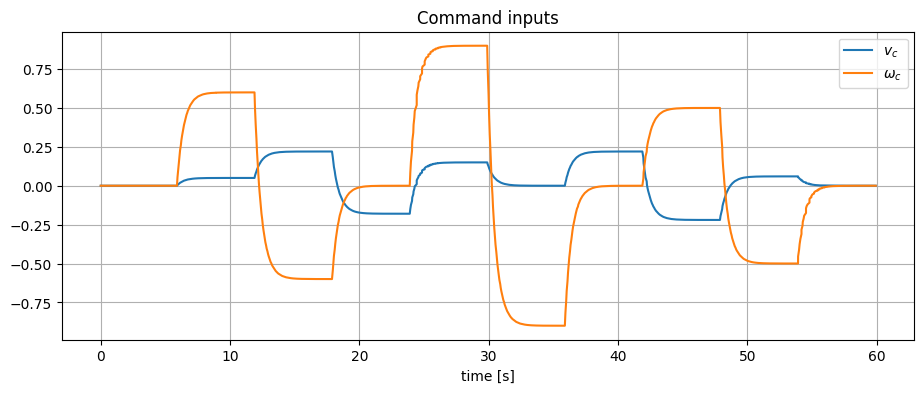

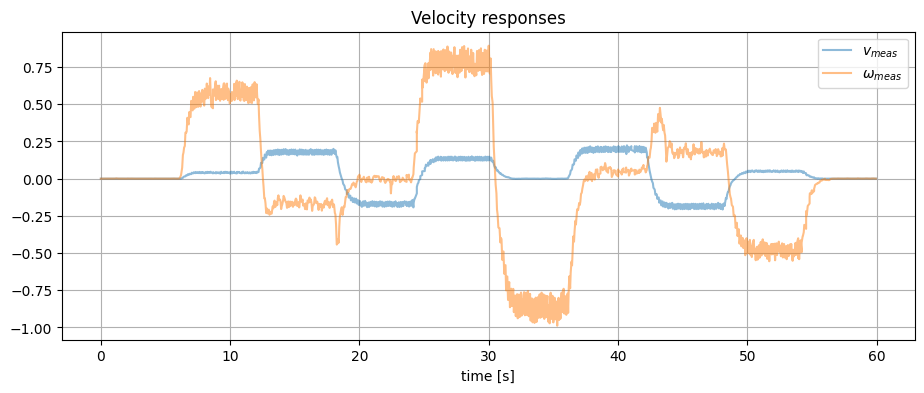

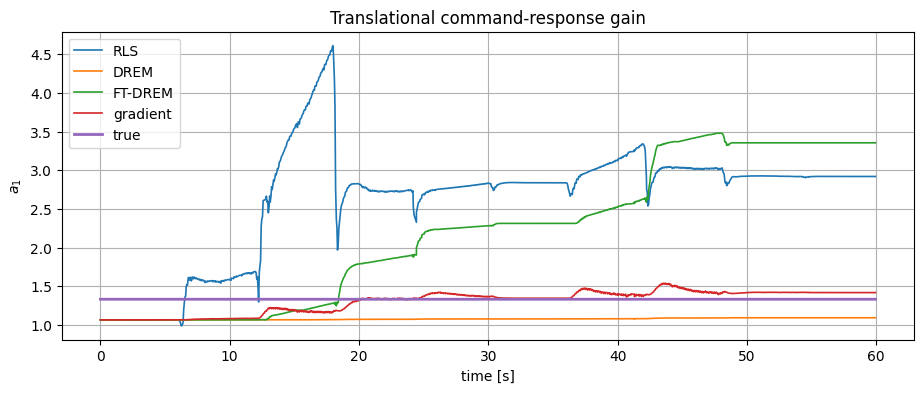

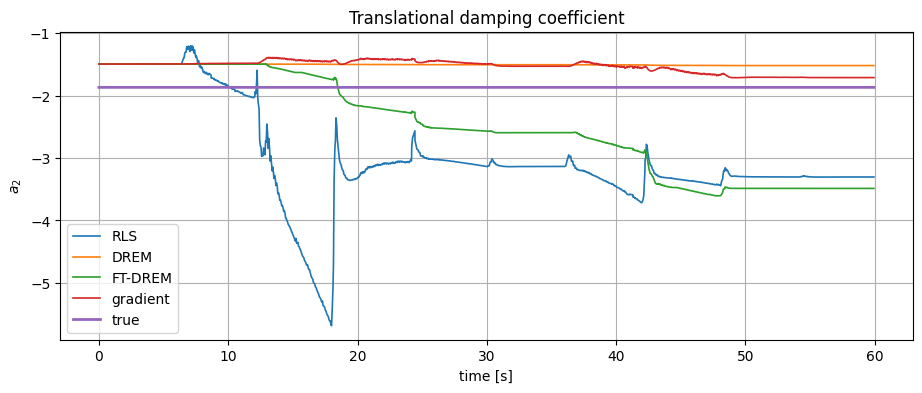

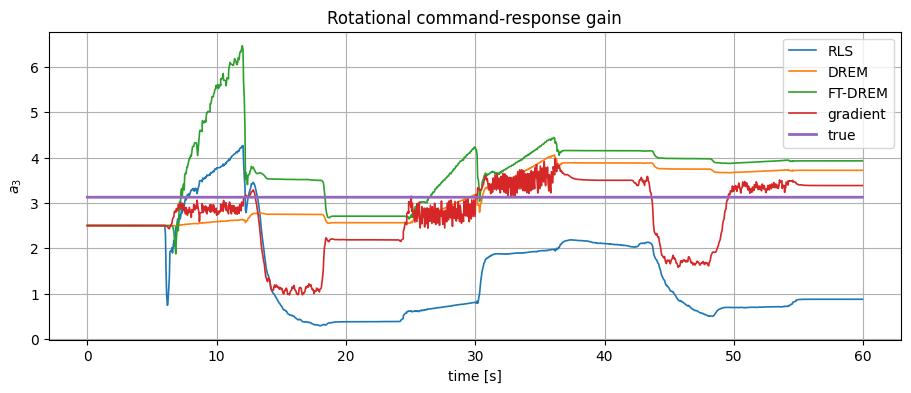

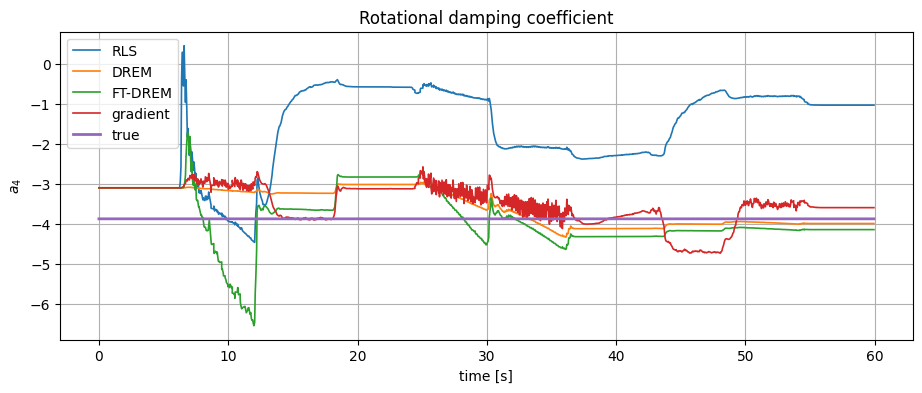

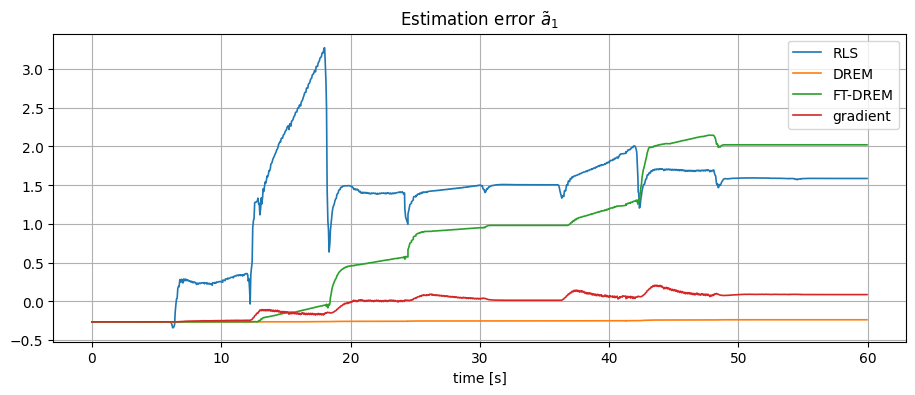

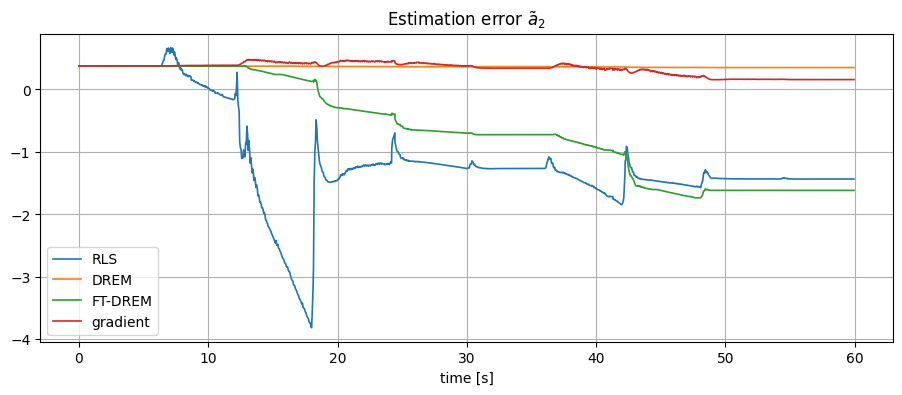

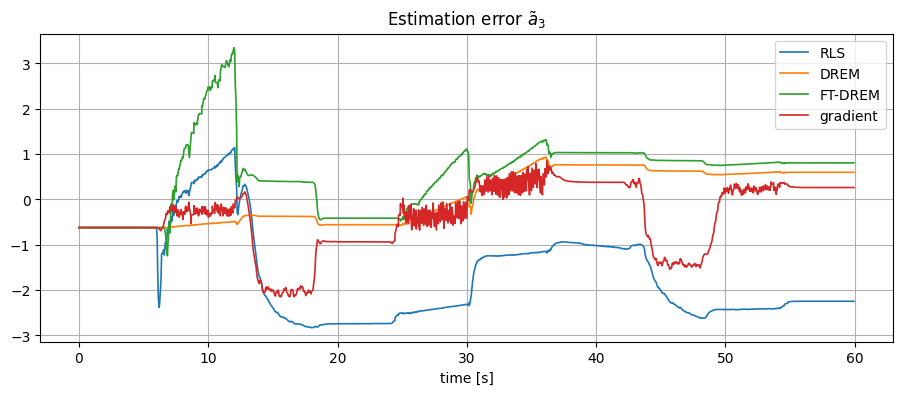

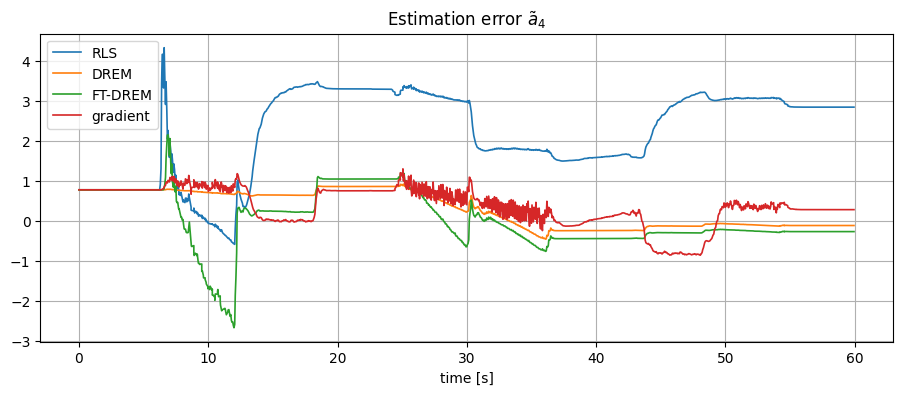

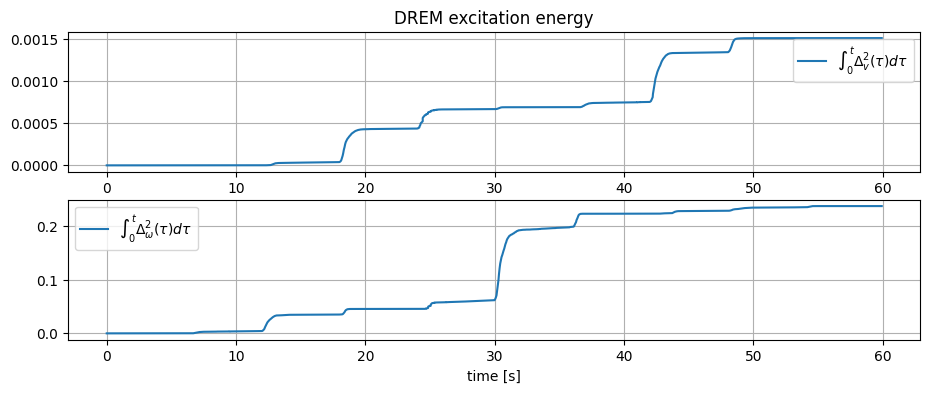

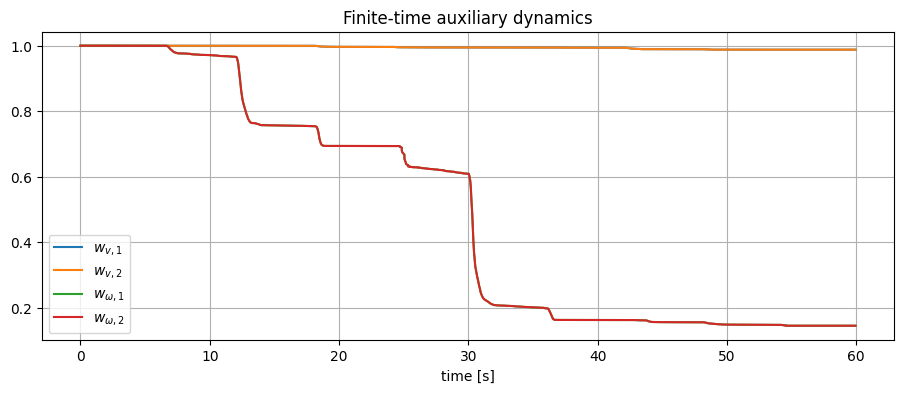

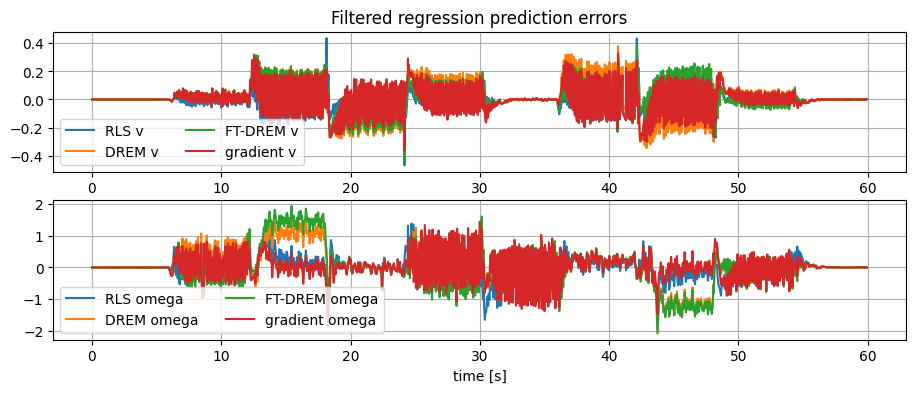

In [41]:
plot_all(exp, exp.record_path)

create_pdf_from_images(
    "images/" + os.path.basename(exp.record_path), 
    f"{os.path.basename(exp.record_path)}.pdf",
    images_to_pdf
)

In [42]:
print(cfg.drem.gamma_v, cfg.drem.gamma_w)

(8.0, 8.0) (8.0, 8.0)


In [43]:
def plot_ftdrem_auxiliary_2(exp: EffectiveInertialResponseExperiment) -> None:
    r = exp.results

    fig, ax = plt.subplots(figsize=(11, 4))

    ax.plot(exp.t, r["w_ftdrem_v"][:, 0], label=r"$w_{v,1}$")
    ax.plot(exp.t, r["w_ftdrem_v"][:, 1], label=r"$w_{v,2}$")
    ax.plot(exp.t, r["w_ftdrem_w"][:, 0], label=r"$w_{\omega,1}$")
    ax.plot(exp.t, r["w_ftdrem_w"][:, 1], label=r"$w_{\omega,2}$")

    ax.axhline(exp.cfg.ftdrem.mu_v[0], color="k", ls="--", lw=1, label=r"$\mu$")

    ax.set_title("Finite-time auxiliary variables")
    ax.set_xlabel("time [s]")
    ax.grid(True)
    ax.legend()

    plt.show()

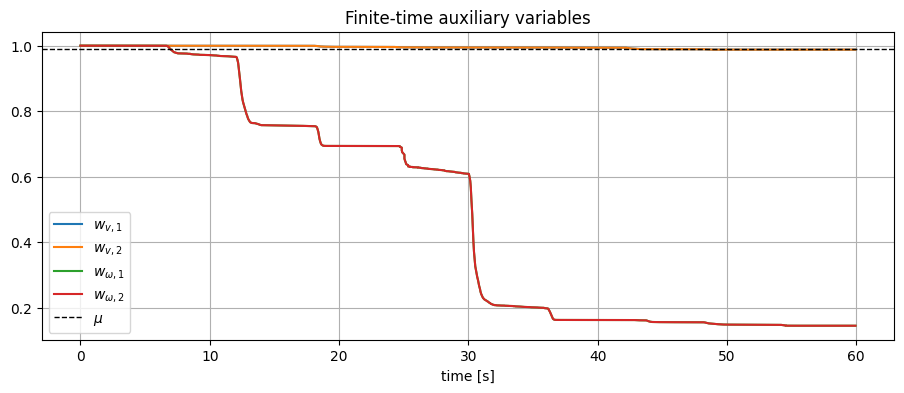

In [44]:
plot_ftdrem_auxiliary_2(exp)